<a href="https://colab.research.google.com/github/muhammadkayed/GSG/blob/main/DATA_W~1_IPY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement
In 2-4 sentences, explain the kind of problem you want to look at and the datasets you will be wrangling for this project.

*FILL IN:* How has the Real GDP per Capita (constant
2015
 US$) evolved over time for Brazil, China, India, South Africa, and the Russian Federation, and how do their latest available values compare?

### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code).

Load the dataset programmtically into this notebook.

#### **Dataset 1**

Type: Excel File.



Method: The data was gathered using the "Downloading files" method from "kaggle" source.

Source URL: "https://www.kaggle.com/datasets/docstein/brics-world-bank-indicators/data?select=BRICS+Economic+Data.xlsx"

This dataset was manually downloaded and contains education and environmental indicators for BRICS countries (Brazil, Russia, India, China, South Africa). Manual download is suitable when data is published in reports or spreadsheets by official organizations.

Dataset variables:

*   *Variable 1 (Country):
                - Represents the name of the BRICS country (Brazil, Russia, India, China, South Africa).
                - This is a categorical variable used to group and compare data across nations.

    *Variable 2 (Country Code):
            	3-letter ISO country code (e.g., BRA)

    *Variable 3 (Series Name):
            	Name of the indicator (e.g., "Access to electricity (% of population)")

    *Variable 4 (Series Code):
            	World Bank or international organization code for the indicator (e.g., EG.ELC.ACCS.ZS)

*   *Variable 5 (Year):
                - Indicates the year of observation for each data entry.
                - Useful for time-series analysis and tracking trends over time.


In [ ]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import kagglehub
import openpyxl
import seaborn as sns


c:\Users\Mohammad\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#FILL IN 1st data gathering and loading method
edu_env_df = pd.read_excel("BRICS Education and Environment Data.xlsx", sheet_name='Data')


#### Dataset 2

Type: Excel File.

Method: The data was gathered using the "API" method from "kaggle" source.

This dataset titled "BRICS Economic Data" appears to contain structured information about key economic indicators for BRICS countries—Brazil, Russia, India, China, and South Africa. Here's a brief overview:

The dataset likely tracks economic metrics across multiple years or quarters for each BRICS country. These metrics help compare and analyze the economic performance and trends among these emerging economies.

Source URL: "https://www.kaggle.com/datasets/docstein/brics-world-bank-indicators/data?select=BRICS+Economic+Data.xlsx"


Dataset variables:

*   *Variable 1 (Country):
                - Represents the name of the BRICS country (Brazil, Russia, India, China, South Africa).
                - This is a categorical variable used to group and compare data across nations.

    *Variable 2 (Country Code):
            	3-letter ISO country code (e.g., BRA)

    *Variable 3 (Series Name):
            	Name of the indicator (e.g., "Access to electricity (% of population)")

    *Variable 4 (Series Code):
            	World Bank or international organization code for the indicator (e.g., EG.ELC.ACCS.ZS)

*   *Variable 5 (Year):
                - Indicates the year of observation for each data entry.
                - Useful for time-series analysis and tracking trends over time.


In [ ]:
#FILL IN 2nd data gathering and loading method
path=kagglehub.dataset_download('docstein/brics-world-bank-indicators', path='BRICS Economic Data.xlsx')
eco_df = pd.read_excel(path, sheet_name='Data')


In [ ]:
eco_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1730 entries, 0 to 1729
Data columns (total 55 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country Name   1727 non-null   object 
 1   Country Code   1725 non-null   object 
 2   Series Name    1725 non-null   object 
 3   Series Code    1725 non-null   object 
 4   1970 [YR1970]  671 non-null    float64
 5   1971 [YR1971]  688 non-null    float64
 6   1972 [YR1972]  694 non-null    float64
 7   1973 [YR1973]  693 non-null    float64
 8   1974 [YR1974]  698 non-null    float64
 9   1975 [YR1975]  802 non-null    float64
 10  1976 [YR1976]  802 non-null    float64
 11  1977 [YR1977]  808 non-null    float64
 12  1978 [YR1978]  807 non-null    float64
 13  1979 [YR1979]  835 non-null    float64
 14  1980 [YR1980]  847 non-null    float64
 15  1981 [YR1981]  882 non-null    float64
 16  1982 [YR1982]  948 non-null    float64
 17  1983 [YR1983]  953 non-null    float64
 18  1984 [YR

Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [ ]:
#Optional: store the raw data in your local data store

## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1:
#### (In Dataset: BRICS Education and Environment Data.xlsx )
##### Completeness Issue:

In [ ]:
#FILL IN - Inspecting the dataframe visually


![AdobePhotoshopExpress_3f430f44a99648d9943af93846f6d15f_CopyEdited.png](attachment:AdobePhotoshopExpress_3f430f44a99648d9943af93846f6d15f_CopyEdited.png)
![image.png](attachment:image.png)

In [ ]:
#FILL IN - Inspecting the dataframe programmatically
edu_env_df.isnull().sum()


Country Name        3
Country Code        5
Series Name         5
Series Code         5
1970 [YR1970]    1063
1971 [YR1971]     952
1972 [YR1972]     978
1973 [YR1973]     975
1974 [YR1974]     990
1975 [YR1975]     983
1976 [YR1976]     969
1977 [YR1977]     960
1978 [YR1978]     979
1979 [YR1979]     986
1980 [YR1980]     956
1981 [YR1981]     955
1982 [YR1982]     943
1983 [YR1983]     988
1984 [YR1984]     985
1985 [YR1985]     980
1986 [YR1986]     954
1987 [YR1987]     905
1988 [YR1988]     944
1989 [YR1989]     910
1990 [YR1990]     735
1991 [YR1991]     788
1992 [YR1992]     782
1993 [YR1993]     814
1994 [YR1994]     726
1995 [YR1995]     739
1996 [YR1996]     809
1997 [YR1997]     772
1998 [YR1998]     808
1999 [YR1999]     703
2000 [YR2000]     581
2001 [YR2001]     646
2002 [YR2002]     579
2003 [YR2003]     631
2004 [YR2004]     680
2005 [YR2005]     664
2006 [YR2006]     692
2007 [YR2007]     575
2008 [YR2008]     620
2009 [YR2009]     624
2010 [YR2010]     579
2011 [YR20

In [ ]:
#FILL IN - Inspecting the dataframe programmatically
edu_env_df.head()

,Country Name,Country Code,Series Name,Series Code,1970 [YR1970],1971 [YR1971],1972 [YR1972],1973 [YR1973],1974 [YR1974],1975 [YR1975],...,2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020]
0,Brazil,BRA,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,94.400002,94.800003,95.000000,95.199997,95.500000,95.599998,95.599998,95.800003,95.900002,NaN
1,Brazil,BRA,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,99.328691,99.519494,99.575151,99.650247,99.710902,99.700000,99.800000,99.700000,99.800000,NaN
2,Brazil,BRA,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,96.190587,97.221813,97.502033,97.910077,98.232409,98.467130,99.169593,98.410908,98.482089,NaN
3,Brazil,BRA,"Access to electricity, urban (% of urban popul...",EG.ELC.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,99.898571,99.927418,99.935013,99.945554,99.956197,99.900000,99.900000,99.900000,100.000000,NaN
4,Brazil,BRA,"Adjusted net enrollment rate, primary (% of pr...",SE.PRM.TENR,NaN,NaN,NaN,NaN,NaN,NaN,...,95.697180,98.549930,97.323890,97.436200,96.852310,97.202020,97.551170,NaN,NaN,NaN


Issue and justification: Missing value especially in "years" columns.

### Quality Issue 2:
##### (In Dataset 2: BRICS Economic Data.xlsx ):
##### Completeness Issue:

In [ ]:
#FILL IN - Inspecting the dataframe visually


![image-3.png](attachment:image-3.png)
![image-2.png](attachment:image-2.png)

In [ ]:
edu_env_df.isnull().sum()


Country Name        3
Country Code        5
Series Name         5
Series Code         5
1970 [YR1970]    1063
1971 [YR1971]     952
1972 [YR1972]     978
1973 [YR1973]     975
1974 [YR1974]     990
1975 [YR1975]     983
1976 [YR1976]     969
1977 [YR1977]     960
1978 [YR1978]     979
1979 [YR1979]     986
1980 [YR1980]     956
1981 [YR1981]     955
1982 [YR1982]     943
1983 [YR1983]     988
1984 [YR1984]     985
1985 [YR1985]     980
1986 [YR1986]     954
1987 [YR1987]     905
1988 [YR1988]     944
1989 [YR1989]     910
1990 [YR1990]     735
1991 [YR1991]     788
1992 [YR1992]     782
1993 [YR1993]     814
1994 [YR1994]     726
1995 [YR1995]     739
1996 [YR1996]     809
1997 [YR1997]     772
1998 [YR1998]     808
1999 [YR1999]     703
2000 [YR2000]     581
2001 [YR2001]     646
2002 [YR2002]     579
2003 [YR2003]     631
2004 [YR2004]     680
2005 [YR2005]     664
2006 [YR2006]     692
2007 [YR2007]     575
2008 [YR2008]     620
2009 [YR2009]     624
2010 [YR2010]     579
2011 [YR20

In [ ]:
#FILL IN - Inspecting the dataframe programmatically
eco_df.info()
eco_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1730 entries, 0 to 1729
Data columns (total 55 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country Name   1727 non-null   object 
 1   Country Code   1725 non-null   object 
 2   Series Name    1725 non-null   object 
 3   Series Code    1725 non-null   object 
 4   1970 [YR1970]  671 non-null    float64
 5   1971 [YR1971]  688 non-null    float64
 6   1972 [YR1972]  694 non-null    float64
 7   1973 [YR1973]  693 non-null    float64
 8   1974 [YR1974]  698 non-null    float64
 9   1975 [YR1975]  802 non-null    float64
 10  1976 [YR1976]  802 non-null    float64
 11  1977 [YR1977]  808 non-null    float64
 12  1978 [YR1978]  807 non-null    float64
 13  1979 [YR1979]  835 non-null    float64
 14  1980 [YR1980]  847 non-null    float64
 15  1981 [YR1981]  882 non-null    float64
 16  1982 [YR1982]  948 non-null    float64
 17  1983 [YR1983]  953 non-null    float64
 18  1984 [YR

,Country Name,Country Code,Series Name,Series Code,1970 [YR1970],1971 [YR1971],1972 [YR1972],1973 [YR1973],1974 [YR1974],1975 [YR1975],...,2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020]
0,Brazil,BRA,Adjusted net national income (annual % growth),NY.ADJ.NNTY.KD.ZG,NaN,1.164947e+01,1.234455e+01,1.199246e+01,5.131874e+00,3.197446e+00,...,5.229621e+00,2.591876e+00,4.128928e+00,-1.420558e-01,-2.944151e+00,-3.120275e+00,8.914463e-01,-1.277959e+00,1.188819e+00,NaN
1,Brazil,BRA,Adjusted net national income (constant 2015 US$),NY.ADJ.NNTY.KD,3.085549e+11,3.444999e+11,3.870269e+11,4.334409e+11,4.556846e+11,4.702548e+11,...,1.546649e+12,1.586736e+12,1.652252e+12,1.649904e+12,1.601329e+12,1.551363e+12,1.565192e+12,1.545190e+12,1.563559e+12,NaN
2,Brazil,BRA,Adjusted net national income (current US$),NY.ADJ.NNTY.CD,3.879944e+10,4.524430e+10,5.381338e+10,7.217868e+10,9.549633e+10,1.113937e+11,...,2.269851e+12,2.149650e+12,2.186978e+12,2.164466e+12,1.601329e+12,1.596448e+12,1.832860e+12,1.644502e+12,1.610061e+12,NaN
3,Brazil,BRA,Adjusted net national income per capita (annua...,NY.ADJ.NNTY.PC.KD.ZG,NaN,8.935440e+00,9.670966e+00,9.363915e+00,2.675231e+00,7.815122e-01,...,4.270155e+00,1.679274e+00,3.223214e+00,-9.929897e-01,-3.754888e+00,-3.915045e+00,8.038341e-02,-2.048761e+00,4.311839e-01,NaN
4,Brazil,BRA,Adjusted net national income per capita (const...,NY.ADJ.NNTY.PC.KD,3.244094e+03,3.533968e+03,3.875737e+03,4.238658e+03,4.352052e+03,4.386064e+03,...,7.830429e+03,7.962194e+03,8.218755e+03,8.137266e+03,7.831540e+03,7.522652e+03,7.531042e+03,7.376673e+03,7.408586e+03,NaN


Issue and justification: Missing value especially in "years" columns.

### Tidiness Issue 1:
#### (In Dataset: BRICS Education and Environment Data.xlsx )

In [ ]:
#FILL IN - Inspecting the dataframe visually

![image-2.png](attachment:image-2.png)
![image-3.png](attachment:image-3.png)

In [ ]:
#FILL IN - Inspecting the dataframe programmatically

edu_env_df.info()
edu_env_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1430 entries, 0 to 1429
Data columns (total 55 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country Name   1427 non-null   object 
 1   Country Code   1425 non-null   object 
 2   Series Name    1425 non-null   object 
 3   Series Code    1425 non-null   object 
 4   1970 [YR1970]  367 non-null    float64
 5   1971 [YR1971]  478 non-null    float64
 6   1972 [YR1972]  452 non-null    float64
 7   1973 [YR1973]  455 non-null    float64
 8   1974 [YR1974]  440 non-null    float64
 9   1975 [YR1975]  447 non-null    float64
 10  1976 [YR1976]  461 non-null    float64
 11  1977 [YR1977]  470 non-null    float64
 12  1978 [YR1978]  451 non-null    float64
 13  1979 [YR1979]  444 non-null    float64
 14  1980 [YR1980]  474 non-null    float64
 15  1981 [YR1981]  475 non-null    float64
 16  1982 [YR1982]  487 non-null    float64
 17  1983 [YR1983]  442 non-null    float64
 18  1984 [YR

,Country Name,Country Code,Series Name,Series Code,1970 [YR1970],1971 [YR1971],1972 [YR1972],1973 [YR1973],1974 [YR1974],1975 [YR1975],...,2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020]
0,Brazil,BRA,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,94.400002,94.800003,95.000000,95.199997,95.500000,95.599998,95.599998,95.800003,95.900002,NaN
1,Brazil,BRA,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,99.328691,99.519494,99.575151,99.650247,99.710902,99.700000,99.800000,99.700000,99.800000,NaN
2,Brazil,BRA,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,96.190587,97.221813,97.502033,97.910077,98.232409,98.467130,99.169593,98.410908,98.482089,NaN
3,Brazil,BRA,"Access to electricity, urban (% of urban popul...",EG.ELC.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,99.898571,99.927418,99.935013,99.945554,99.956197,99.900000,99.900000,99.900000,100.000000,NaN
4,Brazil,BRA,"Adjusted net enrollment rate, primary (% of pr...",SE.PRM.TENR,NaN,NaN,NaN,NaN,NaN,NaN,...,95.697180,98.549930,97.323890,97.436200,96.852310,97.202020,97.551170,NaN,NaN,NaN


Issue and justification: The columns names related to the "Year" is values (e.g. " 1970 [YR1970] ") not variable.

### Tidiness Issue 2:
##### (In Dataset 2: BRICS Economic Data.xlsx ):

In [ ]:
#FILL IN - Inspecting the dataframe visually

![image.png](attachment:image.png)
![image-2.png](attachment:image-2.png)

In [ ]:
#FILL IN - Inspecting the dataframe programmatically
eco_df.info()
eco_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1730 entries, 0 to 1729
Data columns (total 55 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country Name   1727 non-null   object 
 1   Country Code   1725 non-null   object 
 2   Series Name    1725 non-null   object 
 3   Series Code    1725 non-null   object 
 4   1970 [YR1970]  671 non-null    float64
 5   1971 [YR1971]  688 non-null    float64
 6   1972 [YR1972]  694 non-null    float64
 7   1973 [YR1973]  693 non-null    float64
 8   1974 [YR1974]  698 non-null    float64
 9   1975 [YR1975]  802 non-null    float64
 10  1976 [YR1976]  802 non-null    float64
 11  1977 [YR1977]  808 non-null    float64
 12  1978 [YR1978]  807 non-null    float64
 13  1979 [YR1979]  835 non-null    float64
 14  1980 [YR1980]  847 non-null    float64
 15  1981 [YR1981]  882 non-null    float64
 16  1982 [YR1982]  948 non-null    float64
 17  1983 [YR1983]  953 non-null    float64
 18  1984 [YR

,Country Name,Country Code,Series Name,Series Code,1970 [YR1970],1971 [YR1971],1972 [YR1972],1973 [YR1973],1974 [YR1974],1975 [YR1975],...,2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020]
0,Brazil,BRA,Adjusted net national income (annual % growth),NY.ADJ.NNTY.KD.ZG,NaN,1.164947e+01,1.234455e+01,1.199246e+01,5.131874e+00,3.197446e+00,...,5.229621e+00,2.591876e+00,4.128928e+00,-1.420558e-01,-2.944151e+00,-3.120275e+00,8.914463e-01,-1.277959e+00,1.188819e+00,NaN
1,Brazil,BRA,Adjusted net national income (constant 2015 US$),NY.ADJ.NNTY.KD,3.085549e+11,3.444999e+11,3.870269e+11,4.334409e+11,4.556846e+11,4.702548e+11,...,1.546649e+12,1.586736e+12,1.652252e+12,1.649904e+12,1.601329e+12,1.551363e+12,1.565192e+12,1.545190e+12,1.563559e+12,NaN
2,Brazil,BRA,Adjusted net national income (current US$),NY.ADJ.NNTY.CD,3.879944e+10,4.524430e+10,5.381338e+10,7.217868e+10,9.549633e+10,1.113937e+11,...,2.269851e+12,2.149650e+12,2.186978e+12,2.164466e+12,1.601329e+12,1.596448e+12,1.832860e+12,1.644502e+12,1.610061e+12,NaN
3,Brazil,BRA,Adjusted net national income per capita (annua...,NY.ADJ.NNTY.PC.KD.ZG,NaN,8.935440e+00,9.670966e+00,9.363915e+00,2.675231e+00,7.815122e-01,...,4.270155e+00,1.679274e+00,3.223214e+00,-9.929897e-01,-3.754888e+00,-3.915045e+00,8.038341e-02,-2.048761e+00,4.311839e-01,NaN
4,Brazil,BRA,Adjusted net national income per capita (const...,NY.ADJ.NNTY.PC.KD,3.244094e+03,3.533968e+03,3.875737e+03,4.238658e+03,4.352052e+03,4.386064e+03,...,7.830429e+03,7.962194e+03,8.218755e+03,8.137266e+03,7.831540e+03,7.522652e+03,7.531042e+03,7.376673e+03,7.408586e+03,NaN


Issue and justification: The columns names related to the "Year" is values (e.g. " 1970 [YR1970] ") not variable.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [ ]:
# FILL IN - Make copies of the datasets to ensure the raw dataframes
# are not impacted
edu_env_clean_df = edu_env_df.copy()
eco_clean_df = eco_df.copy()

### **Tidiness Issue 1:
#### (In Dataset: BRICS Education and Environment Data.xlsx )**

In [ ]:
#FILL IN - Apply the cleaning strategy
#Unpivot the dataframe from wide to long format using pd.melt() function
edu_env_melted_df = pd.melt(edu_env_clean_df, id_vars=['Country Name','Country Code','Series Name','Series Code'], var_name='Education and Environment Year', value_name='Education and Environment Value')
edu_env_melted_df.head()



,Country Name,Country Code,Series Name,Series Code,Education and Environment Year,Education and Environment Value
0,Brazil,BRA,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,1970 [YR1970],NaN
1,Brazil,BRA,Access to electricity (% of population),EG.ELC.ACCS.ZS,1970 [YR1970],NaN
2,Brazil,BRA,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,1970 [YR1970],NaN
3,Brazil,BRA,"Access to electricity, urban (% of urban popul...",EG.ELC.ACCS.UR.ZS,1970 [YR1970],NaN
4,Brazil,BRA,"Adjusted net enrollment rate, primary (% of pr...",SE.PRM.TENR,1970 [YR1970],NaN


In [ ]:
#Remove any footnotes or special characters from the 'Education and Environment Year' column e.g: remove  [YR1970] from 1970 [YR1970]
edu_env_melted_df['Education and Environment Year'] = edu_env_melted_df['Education and Environment Year'].str.replace(r'\s*\[.*?\]', '', regex=True)

In [ ]:
#FILL IN - Validate the cleaning was successful
edu_env_melted_df.head()

,Country Name,Country Code,Series Name,Series Code,Education and Environment Year,Education and Environment Value
0,Brazil,BRA,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,1970,NaN
1,Brazil,BRA,Access to electricity (% of population),EG.ELC.ACCS.ZS,1970,NaN
2,Brazil,BRA,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,1970,NaN
3,Brazil,BRA,"Access to electricity, urban (% of urban popul...",EG.ELC.ACCS.UR.ZS,1970,NaN
4,Brazil,BRA,"Adjusted net enrollment rate, primary (% of pr...",SE.PRM.TENR,1970,NaN


Justification: Unpivot the "Years" columns in dataframe from wide to long format using pd.melt() function to make dataframe ready to analysis. And remove unnecessary footnotes or special characters from the 'Education and Environment Year' column.  

### **Tidiness Issue 2:
##### (In Dataset 2: BRICS Economic Data.xlsx ):**

In [ ]:
#FILL IN - Apply the cleaning strategy
#Unpivot the dataframe from wide to long format using pd.melt() function
eco_melted_df = pd.melt(eco_clean_df, id_vars=['Country Name','Country Code','Series Name','Series Code'], var_name='Economic Year', value_name='Economic Value')
eco_melted_df.head()

,Country Name,Country Code,Series Name,Series Code,Economic Year,Economic Value
0,Brazil,BRA,Adjusted net national income (annual % growth),NY.ADJ.NNTY.KD.ZG,1970 [YR1970],NaN
1,Brazil,BRA,Adjusted net national income (constant 2015 US$),NY.ADJ.NNTY.KD,1970 [YR1970],3.085549e+11
2,Brazil,BRA,Adjusted net national income (current US$),NY.ADJ.NNTY.CD,1970 [YR1970],3.879944e+10
3,Brazil,BRA,Adjusted net national income per capita (annua...,NY.ADJ.NNTY.PC.KD.ZG,1970 [YR1970],NaN
4,Brazil,BRA,Adjusted net national income per capita (const...,NY.ADJ.NNTY.PC.KD,1970 [YR1970],3.244094e+03


In [ ]:
#Remove any footnotes or special characters from the 'Education and Environment Year' column e.g: remove  [YR1970] from 1970 [YR1970]
eco_melted_df['Economic Year'] = eco_melted_df['Economic Year'].str.replace(r'\s*\[.*?\]', '', regex=True)

In [ ]:
#FILL IN - Validate the cleaning was successful
eco_melted_df.head()

,Country Name,Country Code,Series Name,Series Code,Economic Year,Economic Value
0,Brazil,BRA,Adjusted net national income (annual % growth),NY.ADJ.NNTY.KD.ZG,1970,NaN
1,Brazil,BRA,Adjusted net national income (constant 2015 US$),NY.ADJ.NNTY.KD,1970,3.085549e+11
2,Brazil,BRA,Adjusted net national income (current US$),NY.ADJ.NNTY.CD,1970,3.879944e+10
3,Brazil,BRA,Adjusted net national income per capita (annua...,NY.ADJ.NNTY.PC.KD.ZG,1970,NaN
4,Brazil,BRA,Adjusted net national income per capita (const...,NY.ADJ.NNTY.PC.KD,1970,3.244094e+03


Justification: Unpivot the "Years" columns in dataframe from wide to long format using pd.melt() function to make dataframe ready to analysis. And remove unnecessary   footnotes or special characters from the 'Economic Year' column.  

### **Quality Issue 1: Completeness Issue**
#### (In Dataset: BRICS Education and Environment Data.xlsx )

In [ ]:
# FILL IN - Validate the cleaning was successful
#Calculate the percentage of missing values in each column
missing_percentage = edu_env_melted_df.isnull().mean() * 100
print(missing_percentage)

Country Name                        0.209790
Country Code                        0.349650
Series Name                         0.349650
Series Code                         0.349650
Education and Environment Year      0.000000
Education and Environment Value    57.005348
dtype: float64


In [ ]:
#The percentage of missing values in 'Education and Environment Value' column is 57% which is high. So, we will drop the this column.
print(edu_env_melted_df.columns)
if 'Education and Environment Value' in edu_env_melted_df.columns:
    edu_env_melted_df = edu_env_melted_df.drop('Education and Environment Value', axis=1)
#The Percentage of missing values in 'Country Name', 'Country Code', 'Series Name', 'Series Code', and 'Education and Environment Year' columns are low. So, we will drop the rows with missing values in these columns.
edu_env_melted_df = edu_env_melted_df.dropna(subset=['Country Name', 'Country Code', 'Series Name', 'Series Code', 'Education and Environment Year'])


Index(['Country Name', 'Country Code', 'Series Name', 'Series Code',
       'Education and Environment Year', 'Education and Environment Value'],
      dtype='object')


In [ ]:
#FILL IN - Validate the cleaning was successful
#Calculate the percentage of missing values in each column
missing_percentage = edu_env_melted_df.isnull().mean() * 100
print(missing_percentage)

Country Name                      0.0
Country Code                      0.0
Series Name                       0.0
Series Code                       0.0
Education and Environment Year    0.0
dtype: float64


Justification: I dropped 'Education and Environment Value' column because the  percentage of missing values in this column is 57% which is high. After that I  dropped the rows with missing values in other columns because the Percentage of missing values in these columns is low.

### **Quality Issue 2: Completeness Issue:**
##### (In Dataset 2: BRICS Economic Data.xlsx ):

In [ ]:
#FILL IN - Apply the cleaning strategy
#get the percentage of missing values in each column
missing_percentage = eco_melted_df.isnull().mean() * 100
print(missing_percentage)



Country Name       0.173410
Country Code       0.289017
Series Name        0.289017
Series Code        0.289017
Economic Year      0.000000
Economic Value    30.071404
dtype: float64


In [ ]:
# Drop rows where 'Country Name','Country Code','Series Name' and 'Series Code' is missing
eco_melted_df.dropna(subset=['Country Name'],inplace=True)
eco_melted_df.dropna(subset=['Country Code'],inplace=True)
eco_melted_df.dropna(subset=['Series Name'],inplace=True)
eco_melted_df.dropna(subset=['Series Code'],inplace=True)

# Calculate the mean of 'Economic Value' for each 'Series Code'
mean_by_series = eco_melted_df.groupby('Series Code')['Economic Value'].transform('mean')
# Impute missing values in 'Economic Value' with the calculated group means
eco_melted_df['Economic Value'] = eco_melted_df['Economic Value'].fillna(mean_by_series)
eco_melted_df.head()

,Country Name,Country Code,Series Name,Series Code,Economic Year,Economic Value
0,Brazil,BRA,Adjusted net national income (annual % growth),NY.ADJ.NNTY.KD.ZG,1970,4.613430e+00
1,Brazil,BRA,Adjusted net national income (constant 2015 US$),NY.ADJ.NNTY.KD,1970,3.085549e+11
2,Brazil,BRA,Adjusted net national income (current US$),NY.ADJ.NNTY.CD,1970,3.879944e+10
3,Brazil,BRA,Adjusted net national income per capita (annua...,NY.ADJ.NNTY.PC.KD.ZG,1970,3.150301e+00
4,Brazil,BRA,Adjusted net national income per capita (const...,NY.ADJ.NNTY.PC.KD,1970,3.244094e+03


In [ ]:
missing_percentage = eco_melted_df.isnull().mean() * 100
print(missing_percentage)

Country Name      0.000000
Country Code      0.000000
Series Name       0.000000
Series Code       0.000000
Economic Year     0.000000
Economic Value    3.768116
dtype: float64


In [ ]:
#Drop any remaining rows with missing values
eco_melted_df.dropna(inplace=True)

In [ ]:
#FILL IN - Validate the cleaning was successful
missing_percentage = eco_melted_df.isnull().mean() * 100
print(missing_percentage)

Country Name      0.0
Country Code      0.0
Series Name       0.0
Series Code       0.0
Economic Year     0.0
Economic Value    0.0
dtype: float64


In [ ]:
#Check duplecates
edu_env_melted_df.duplicated()
eco_melted_df.duplicated()


0        False
1        False
2        False
3        False
4        False
         ...  
88220    False
88221    False
88222    False
88223    False
88224    False
Length: 84660, dtype: bool

In [ ]:
#Remove duplecates
edu_env_melted_df.drop_duplicates()
eco_melted_df.drop_duplicates()


,Country Name,Country Code,Series Name,Series Code,Economic Year,Economic Value
0,Brazil,BRA,Adjusted net national income (annual % growth),NY.ADJ.NNTY.KD.ZG,1970,4.613430e+00
1,Brazil,BRA,Adjusted net national income (constant 2015 US$),NY.ADJ.NNTY.KD,1970,3.085549e+11
2,Brazil,BRA,Adjusted net national income (current US$),NY.ADJ.NNTY.CD,1970,3.879944e+10
3,Brazil,BRA,Adjusted net national income per capita (annua...,NY.ADJ.NNTY.PC.KD.ZG,1970,3.150301e+00
4,Brazil,BRA,Adjusted net national income per capita (const...,NY.ADJ.NNTY.PC.KD,1970,3.244094e+03
...,...,...,...,...,...,...
88220,South Africa,ZAF,"Transport services (% of service exports, BoP)",BX.GSR.TRAN.ZS,2020,1.605068e+01
88221,South Africa,ZAF,"Transport services (% of service imports, BoP)",BM.GSR.TRAN.ZS,2020,3.451662e+01
88222,South Africa,ZAF,"Travel services (% of service exports, BoP)",BX.GSR.TRVL.ZS,2020,3.013522e+01
88223,South Africa,ZAF,"Travel services (% of service imports, BoP)",BM.GSR.TRVL.ZS,2020,8.207099e+00


Justification: Because the Percentage of missing value in "Economic Value" column is "30%" I imputed messing value with mean in "Economic Value" column for each "Series Code".
Note: Each "Series Code" has different  metric for "Economic Value" so we cannot apply the same imputation for all "Economic Values" so I use calculated grouped means for each "Series Code".

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [ ]:
#Chick memory usage
edu_env_melted_df.info()
eco_melted_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 72675 entries, 0 to 72924
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Country Name                    72675 non-null  object
 1   Country Code                    72675 non-null  object
 2   Series Name                     72675 non-null  object
 3   Series Code                     72675 non-null  object
 4   Education and Environment Year  72675 non-null  object
dtypes: object(5)
memory usage: 3.3+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 84660 entries, 0 to 88224
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    84660 non-null  object 
 1   Country Code    84660 non-null  object 
 2   Series Name     84660 non-null  object 
 3   Series Code     84660 non-null  object 
 4   Economic Year   84660 non-null  object 
 5   Economic Value

In [ ]:
#Reduce memory usage
#change type of 'Education and Environment Year' and 'Economic Year' columns to integer

edu_env_melted_df['Country Name'] = edu_env_melted_df['Country Name'].astype('category')
edu_env_melted_df['Country Code'] = edu_env_melted_df['Country Code'].astype('category')
edu_env_melted_df['Series Name'] = edu_env_melted_df['Country Name'].astype('category')
edu_env_melted_df['Series Code'] = edu_env_melted_df['Series Code'].astype('category')
edu_env_melted_df['Education and Environment Year'] = edu_env_melted_df['Education and Environment Year'].astype('int16')

eco_melted_df['Country Name'] = eco_melted_df['Country Name'].astype('category')
eco_melted_df['Country Code'] = eco_melted_df['Country Code'].astype('category')
eco_melted_df['Series Name'] = eco_melted_df['Country Name'].astype('category')
eco_melted_df['Series Code'] = eco_melted_df['Series Code'].astype('category')
eco_melted_df['Economic Year'] = eco_melted_df['Economic Year'].astype('int16')


In [ ]:
#Chick memory usage
edu_env_melted_df.info()
eco_melted_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72675 entries, 0 to 72924
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Country Name                    72675 non-null  category
 1   Country Code                    72675 non-null  category
 2   Series Name                     72675 non-null  category
 3   Series Code                     72675 non-null  category
 4   Education and Environment Year  72675 non-null  int16   
dtypes: category(4), int16(1)
memory usage: 1.1 MB
<class 'pandas.core.frame.DataFrame'>
Index: 84660 entries, 0 to 88224
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Country Name    84660 non-null  category
 1   Country Code    84660 non-null  category
 2   Series Name     84660 non-null  category
 3   Series Code     84660 non-null  category
 4   Economic Year   84660 non-nu

In [ ]:
#FILL IN - Remove unnecessary variables and combine datasets
#Remove 'Series Name' and 'Series Code' columns from "edu_env_melted_df" dataframe as they are not needed for the analysis
if 'Series Name' in edu_env_melted_df.columns:
    edu_env_melted_df = edu_env_melted_df.drop(['Series Name'], axis=1)
if 'Series Name' in edu_env_melted_df.columns:
    edu_env_melted_df = edu_env_melted_df.drop(['Series Code'], axis=1)

#Drop 'Education and Environment Year' column as it is not needed for the analysis


if 'Education and Environment Year' in edu_env_melted_df.columns:
    edu_env_melted_df = edu_env_melted_df.drop('Education and Environment Year', axis=1)

    #Because this error (MemoryError: Unable to allocate 9.17 GiB for an array with shape (1230533100,) and data type int64 ) I will drop all record except distinct countries
#select distinct 'Country Code' and 'Country Name' from edu_env_melted_df
distinct_countries = edu_env_melted_df[['Country Code', 'Country Name']].dropna().drop_duplicates().reset_index(drop=True)
distinct_countries.head(10)
merged_df = pd.merge(distinct_countries, eco_melted_df, on="Country Code", how="inner")
merged_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84660 entries, 0 to 84659
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Country Code    84660 non-null  category
 1   Country Name_x  84660 non-null  category
 2   Country Name_y  84660 non-null  category
 3   Series Name     84660 non-null  category
 4   Series Code     84660 non-null  category
 5   Economic Year   84660 non-null  int16   
 6   Economic Value  84660 non-null  float64 
dtypes: category(5), float64(1), int16(1)
memory usage: 1.3 MB


## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [ ]:
#FILL IN - saving data
#Save the cleaned and merged dataframe to a new Excel file
merged_df.to_excel("BRICS Cleaned and Merged Data_Clean.xlsx", index=False)

## 5. Answer the research question

### **5.1:** Define and answer the research question
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Research question:* FILL IN from answer to Step 1

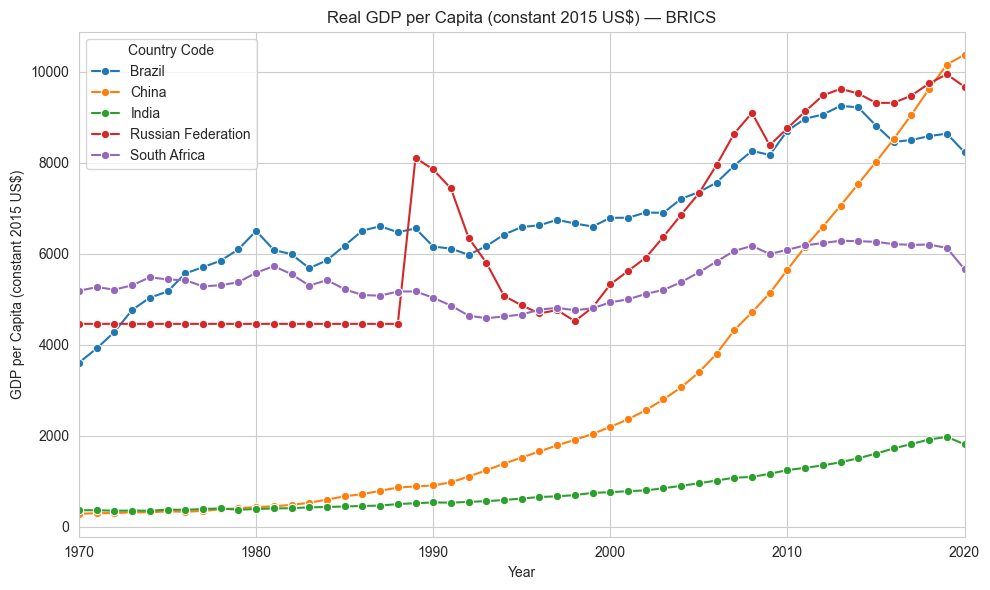

In [ ]:
#Visual 1 - FILL IN
# Filter and plot Real GDP per Capita (constant 2015 US$) for BRICS countries
# Uses existing eco_melted_df in the notebook.

# Define target country codes (stable identifiers)
target_codes = ['BRA', 'CHN', 'IND', 'ZAF', 'RUS']

# Try to find the series corresponding to "Real GDP per Capita (constant 2015 US$)"
candidates = merged_df[
    merged_df['Series Name'].str.contains('per capita', case=False, na=False) &
    merged_df['Series Name'].str.contains('constant', case=False, na=False)
]

# Prefer series names that explicitly mention 2015
priority = candidates[candidates['Series Name'].str.contains('2015', case=False, na=False)]

if not priority.empty:
    series_codes = priority['Series Code'].unique().tolist()
elif not candidates.empty:
    series_codes = candidates['Series Code'].unique().tolist()
else:
    # fallback: search for common GDP per capita code if present
    fallback_codes = ['NY.GDP.PCAP.KD', 'NY.GDP.PCAP.KD.ZG', 'NY.GDP.PCAP.KD.ZG']  # common World Bank codes
    series_codes = [c for c in fallback_codes if c in eco_melted_df['Series Code'].unique()]

if not series_codes:
    raise ValueError("Could not locate a 'GDP per capita (constant ...)' series in eco_melted_df. "
                     "Inspect eco_melted_df['Series Name'].unique() to find the correct series.")

# Select the series (if multiple, take the first that matches)
selected_code = series_codes[0]

# Filter dataframe for the selected series and target countries
gdp_pc = merged_df[
    (merged_df['Series Code'] == selected_code) &
    (merged_df['Country Code'].isin(target_codes))
].copy()

# Ensure types are correct
gdp_pc['Economic Year'] = gdp_pc['Economic Year'].astype(int)
gdp_pc['Economic Value'] = pd.to_numeric(gdp_pc['Economic Value'], errors='coerce')

# 1) Line plot: evolution over time for each country
import matplotlib.pyplot as plt
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
# use Country Code for consistent legend labels; map to full names if available
sns.lineplot(data=gdp_pc, x='Economic Year', y='Economic Value', hue='Country Name_x', marker='o')
plt.title('Real GDP per Capita (constant 2015 US$) — BRICS')
plt.xlabel('Year')
plt.ylabel('GDP per Capita (constant 2015 US$)')
plt.xlim(gdp_pc['Economic Year'].min(), gdp_pc['Economic Year'].max())
plt.legend(title='Country Code')
plt.tight_layout()
plt.show()




*Answer to research question:*
The line chart upove illustrates the historical trend of Real GDP per Capita for the five countries, revealing distinct growth patterns.

1-Russian Federation and South Africa generally maintained higher GDP per capita levels until the early 2000s.

2-Brazil has shown a volatile pattern but remains in the middle of the group.

3-China and India started with significantly lower GDP per capita in
1970
, but China has experienced explosive, almost continuous growth since the late
1970
s, dramatically surpassing South Africa and Brazil around
2007
.

4-India has also seen steady growth, though at a slower pace than China.

In [ ]:
#Visual 2 - Bar plot: latest available value per country (most recent year with data)

import pandas as pd
import altair as alt


df_gdp_pc=gdp_pc
# Define the five countries of interest
top_5_countries = ['Brazil', 'China', 'India', 'South Africa', 'Russian Federation']

# Filter the data for these top 5 countries
df_top_5_gdp_pc = df_gdp_pc[df_gdp_pc['Country Name_x'].isin(top_5_countries)]

# Prepare data for Visualization 2 (Latest Year Comparison)
# Find the row with the maximum 'Economic Year' (latest data point) for each country
df_latest_year = df_top_5_gdp_pc.loc[df_top_5_gdp_pc.groupby('Country Name_x')['Economic Year'].idxmax()]
# Sort by Economic Value in descending order for the bar chart
df_latest_year = df_latest_year.sort_values('Economic Value', ascending=False)

# Title variable for charts
series_title = "Real GDP per Capita (Constant 2015 US$)"

# --- Visualization 2: Bar Chart for Latest Year Comparison ---

chart2 = alt.Chart(df_latest_year).mark_bar().encode(
    # Sort the x-axis by the y-axis value ('-y' for descending)
    x=alt.X('Country Name_x:N', sort='-y', title='Country'),
    y=alt.Y('Economic Value:Q', title=series_title),
    color=alt.Color('Country Name_x:N', title='Country'),
    tooltip=[
        alt.Tooltip('Country Name_x', title='Country'),
        alt.Tooltip('Economic Year', title='Latest Year'),
        alt.Tooltip('Economic Value', title=series_title, format='$,.0f')
    ]
)

# Add text labels on the bars for the actual value
text = chart2.mark_text(
    align='center',
    baseline='bottom',
    dy=-5  # Nudge text to be above the bar
).encode(
    text=alt.Text('Economic Value:Q', format='$,.0f'),
    color=alt.value('black')
)

# Combine the bar chart and the text labels
final_chart2 = (chart2 + text).properties(
    title=f"{series_title} in the Latest Available Year ({df_latest_year['Economic Year'].max()}) for Top 5 Countries"
).interactive()

#change the width and height of the chart
final_chart2 = final_chart2.properties(width=600, height=400)

# To save the chart to a file (uncomment if needed)
# final_chart2.save('gdp_per_capita_bar_chart_latest_year.json')

# If running in an Altair-compatible environment (like a Jupyter Notebook), you can display it:
final_chart2.show()

C:\Users\Mohammad\AppData\Local\Temp\ipykernel_15892\4262790208.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_latest_year = df_top_5_gdp_pc.loc[df_top_5_gdp_pc.groupby('Country Name_x')['Economic Year'].idxmax()]


alt.LayerChart(...)

*Answer to research question:* Real GDP per Capita in the Latest Available Year (Bar Chart)  
The bar chart provides a direct comparison of the latest available Real GDP per Capita figures, which is for the year
2020
 for all five countries.

1-China  has the highest Real GDP per Capita at approximately
$10,730.

2-Russian Federation is second, with a value of approximately
$9,667.

3-Brazil follows at approximately
$8,229.

4-South Africa follows at approximately
$5,659.

5-India has the lowest Real GDP per Capita among the group, at approximately
$1,812.

The comparison highlights the successful economic catch-up and overtaking achieved by the China and Russian Federation  compared to the other three economies.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:* If I had more time and my laptop have more memory, I would work with full data in "BRICS Education and Environment Data" memory.Also  I would examine the
the missing 'BRICS Education and Environment Data' data to understand its pattern. And I would  explore new research questions comparing the growth rate of different economic indicators (e.g., GDP vs. GNI) over recent decades, and analyze the relationship between environmental indicators (like
CO2 emissions, if present) and economic growth across the five nations.